In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import plotly.express as px
from statsmodels.stats.multicomp import MultiComparison

In [2]:
df=pd.read_csv('Employee_Performance-1.csv')
df.head()

,EmployeeID,Department,Gender,Experience,TrainingHours,PerformanceRating,Salary
0,1001,IT,Male,4,5,1.00,19000
1,1002,Marketing,Female,0,50,5.50,6900
2,1003,Sales,Male,0,5,1.00,6000
3,1004,HR,Male,1,5,1.00,6000
4,1005,HR,Female,9,5,1.04,38000


`Experience_category based on years of experience`

In [3]:
levels=[]
for i in df['Experience']:
    if i >=8:
        levels.append('Senior')
    elif i>=5:
        levels.append('Mid-level')
    elif i >=2:
        levels.append('Junior')
    else:
        levels.append('Entry-level')

df['Experience_category']=levels

In [4]:
df.head()

,EmployeeID,Department,Gender,Experience,TrainingHours,PerformanceRating,Salary,Experience_category
0,1001,IT,Male,4,5,1.00,19000,Junior
1,1002,Marketing,Female,0,50,5.50,6900,Entry-level
2,1003,Sales,Male,0,5,1.00,6000,Entry-level
3,1004,HR,Male,1,5,1.00,6000,Entry-level
4,1005,HR,Female,9,5,1.04,38000,Senior


In [5]:
df.shape

(1468, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   EmployeeID           1468 non-null   int64  
 1   Department           1468 non-null   object 
 2   Gender               1468 non-null   object 
 3   Experience           1468 non-null   int64  
 4   TrainingHours        1468 non-null   int64  
 5   PerformanceRating    1468 non-null   float64
 6   Salary               1468 non-null   int64  
 7   Experience_category  1468 non-null   object 
dtypes: float64(1), int64(4), object(3)
memory usage: 91.9+ KB


In [7]:
df.isnull().sum()


EmployeeID             0
Department             0
Gender                 0
Experience             0
TrainingHours          0
PerformanceRating      0
Salary                 0
Experience_category    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,EmployeeID,Experience,TrainingHours,PerformanceRating,Salary
count,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000
mean,1734.500000,2.838556,32.144414,3.561512,16107.623297
std,423.919411,2.527657,10.106029,1.044987,12158.438481
min,1001.000000,0.000000,5.000000,1.000000,6000.000000
25%,1367.750000,1.000000,25.000000,2.840000,7700.000000
50%,1734.500000,2.000000,31.000000,3.630000,10100.000000
75%,2101.250000,4.000000,39.000000,4.330000,20000.000000
max,2468.000000,9.000000,50.000000,5.500000,53100.000000


In [10]:
numerical_col=df.select_dtypes('number').columns.tolist()
categorical_col=df.select_dtypes('object').columns.tolist()
print("Categorical variables: ",categorical_col)
print("Numerical variables: ",numerical_col)

Categorical variables:  ['Department', 'Gender', 'Experience_category']
Numerical variables:  ['EmployeeID', 'Experience', 'TrainingHours', 'PerformanceRating', 'Salary']


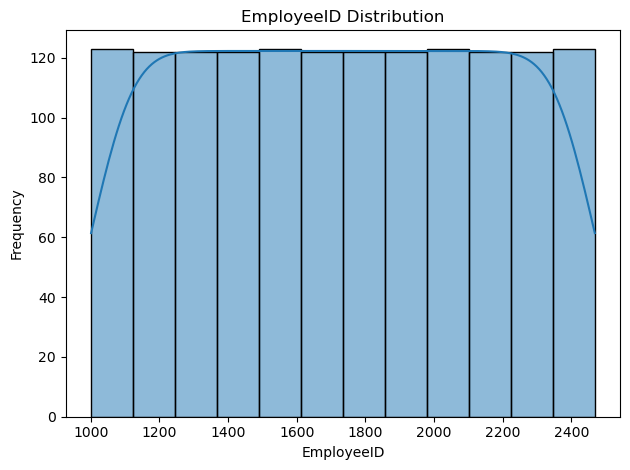

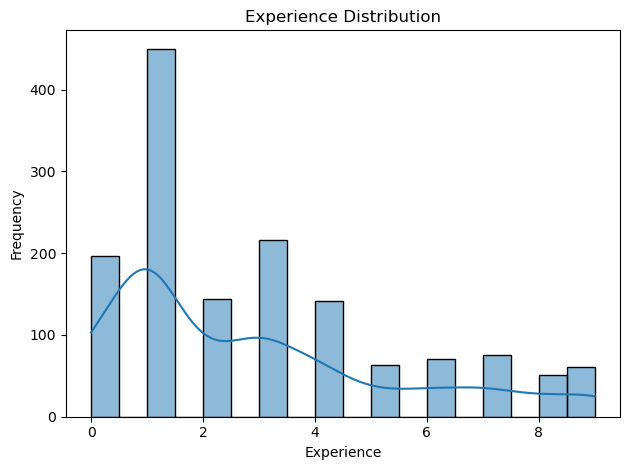

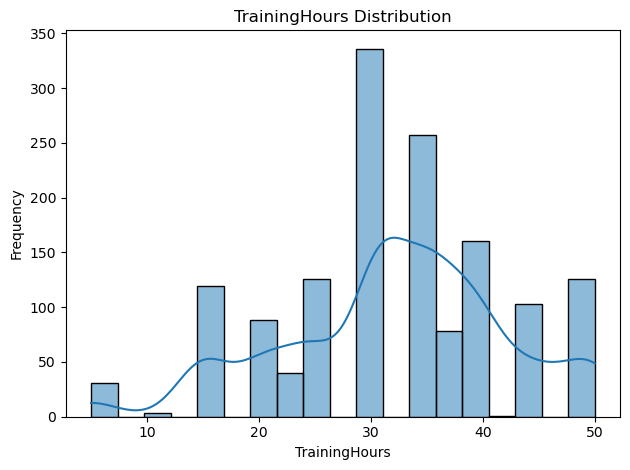

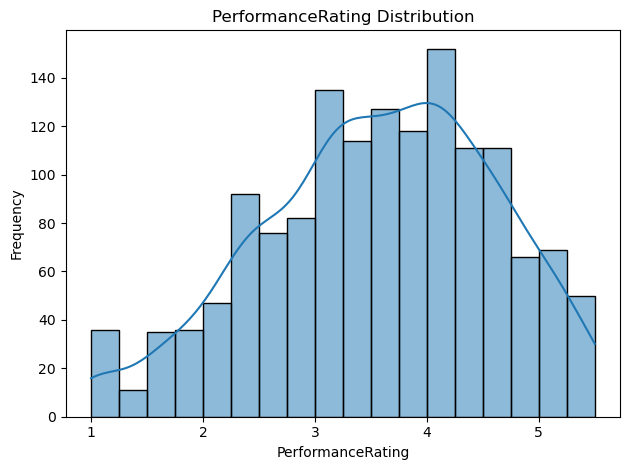

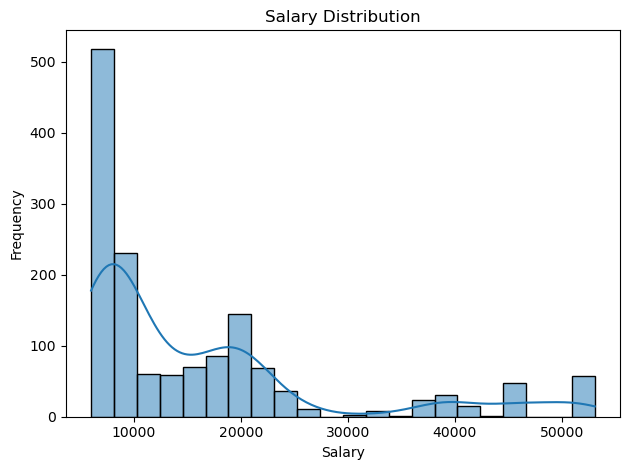

In [11]:
for column in numerical_col:
    sns.histplot(data=df[column],kde=True)
    plt.title(f'{column} Distribution')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [12]:
for column in categorical_col:
    print(df[column].value_counts())
    fig=px.bar(df[column].value_counts(),
               color=df[column].value_counts().index,
               title=f'{column} Distribution ')
    fig.update_layout(yaxis_title='Frequency')
    fig.show()


Department
IT           720
Sales        445
Marketing    240
HR            63
Name: count, dtype: int64


Gender
Male      883
Female    585
Name: count, dtype: int64


Experience_category
Entry-level    647
Junior         501
Mid-level      208
Senior         112
Name: count, dtype: int64


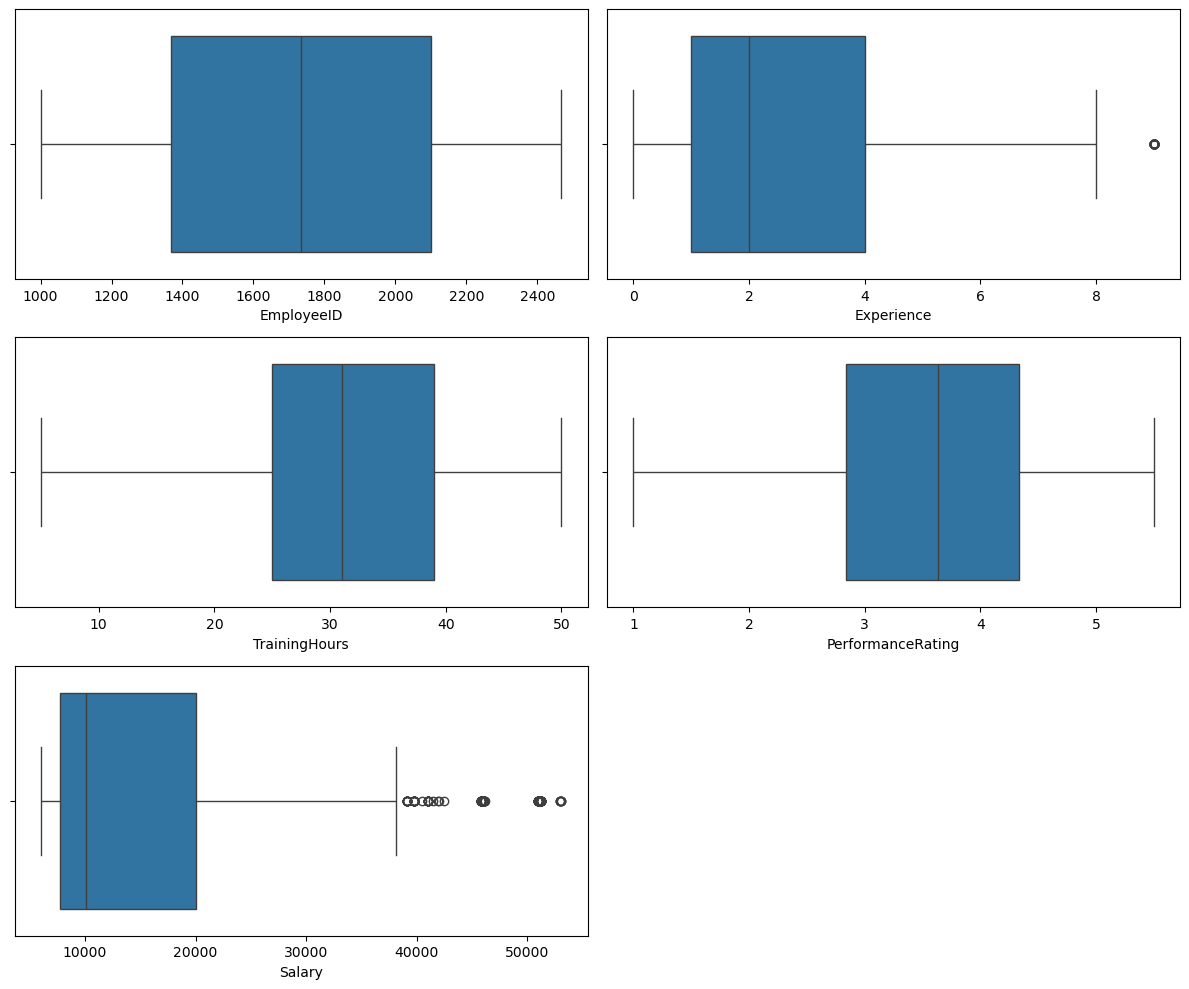

In [13]:
fig,axes=plt.subplots(3,2,figsize=(12,10))
axes=axes.flatten()

for i,col in enumerate(numerical_col):
    sns.boxplot(x=df[col],ax=axes[i])
for j in range(len(numerical_col),len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

`Skewness calculation`

In [14]:
skew_df=df[numerical_col].skew().reset_index()
skew_df.columns=['Attribute','Skewness']
skew_df['Distribution']=skew_df['Skewness'].apply(lambda x: 'Symmetric' if abs(x) <= 0.5 else 'Skewed' )
skew_df['Skewness']=skew_df["Skewness"].round(2)
print(skew_df)

           Attribute  Skewness Distribution
0         EmployeeID      0.00    Symmetric
1         Experience      0.95       Skewed
2      TrainingHours     -0.38    Symmetric
3  PerformanceRating     -0.31    Symmetric
4             Salary      1.63       Skewed


`identify outliers`

In [15]:
outlier_variables=[]
print(numerical_col)
mask_outlier=pd.DataFrame(index=df.index,columns=numerical_col)

#IQR method
for column in numerical_col:
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    mask_outlier[column]=(df[column]<lower_bound)|(df[column]>upper_bound)
    count_outlier = mask_outlier[column].sum()
    mask_outlier=mask_outlier.astype(bool)
    print(count_outlier)
    if count_outlier>0:
        outlier_variables.append(column)  
print(outlier_variables,'\n')



['EmployeeID', 'Experience', 'TrainingHours', 'PerformanceRating', 'Salary']
0
61
0
0
152
['Experience', 'Salary'] 



In [16]:
print((df[mask_outlier]['Experience']).count())

61


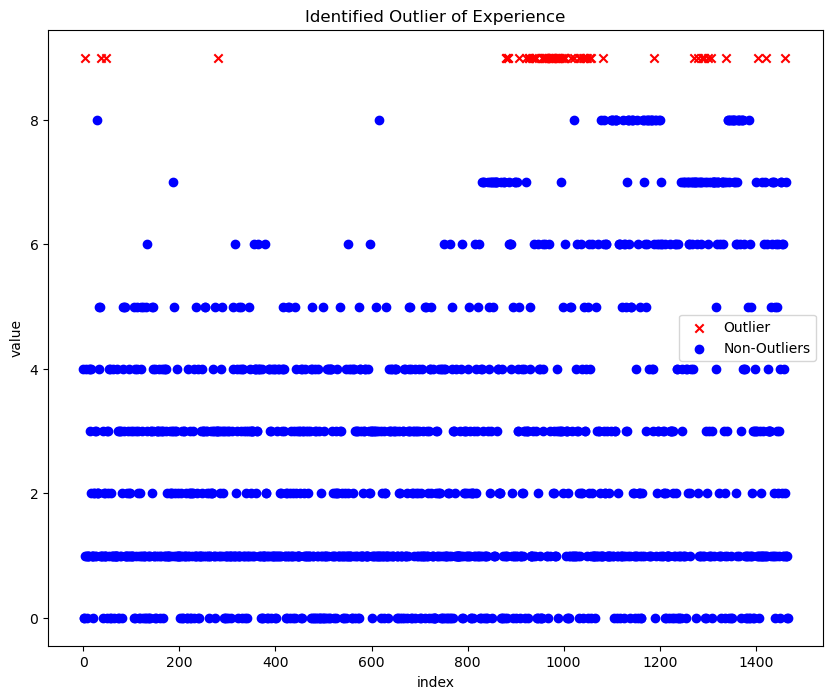

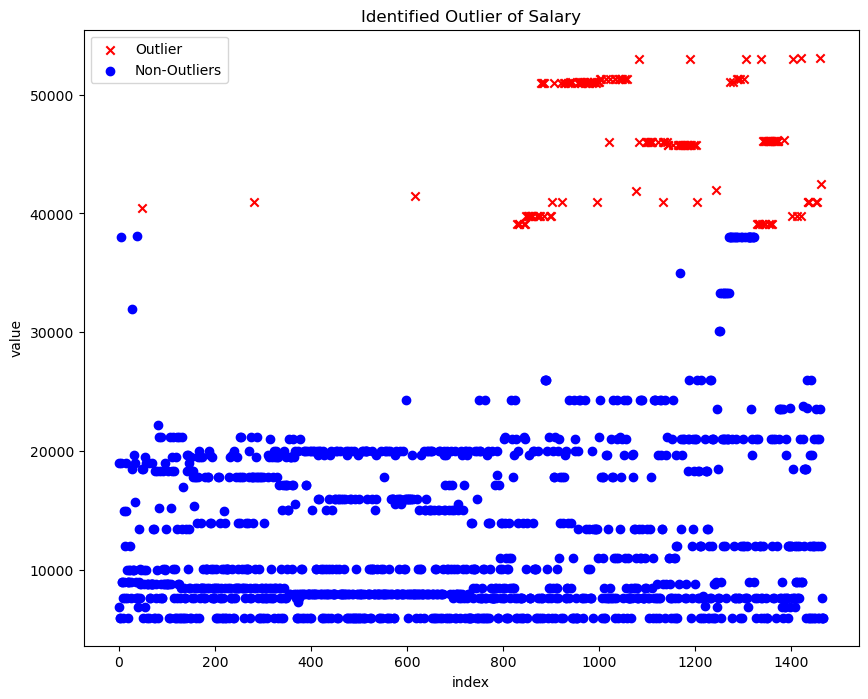

In [17]:
for col in outlier_variables:
    plt.figure(figsize=(10,8))
    plt.scatter(df.index[mask_outlier[col]],df[col][mask_outlier[col]],
    marker='x',label='Outlier',color='red')
    plt.scatter(df.index[~mask_outlier[col]],df[col][~mask_outlier[col]],
    marker='o',label='Non-Outliers',color='blue')
    plt.xlabel("index")
    plt.ylabel("value")
    plt.legend()
    plt.title(f"Identified Outlier of {col}")
    plt.show()

In [18]:
print(df['Department'].value_counts())



Department
IT           720
Sales        445
Marketing    240
HR            63
Name: count, dtype: int64


<Axes: >

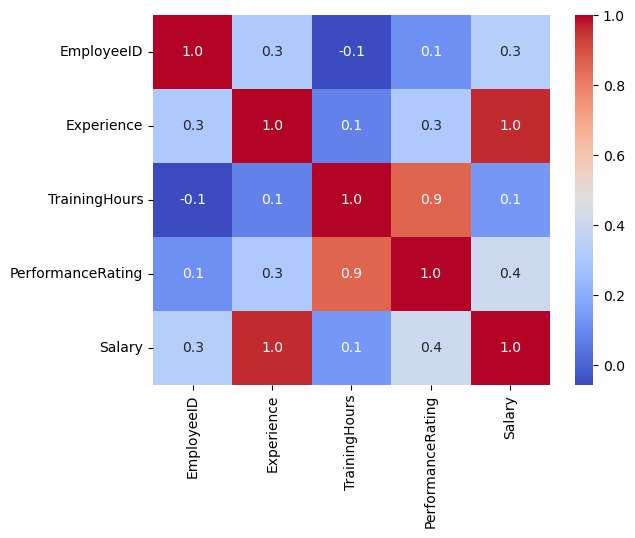

In [19]:
corr=df[numerical_col].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.1f')

In [20]:
print(sorted(df['Experience'].dropna().unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


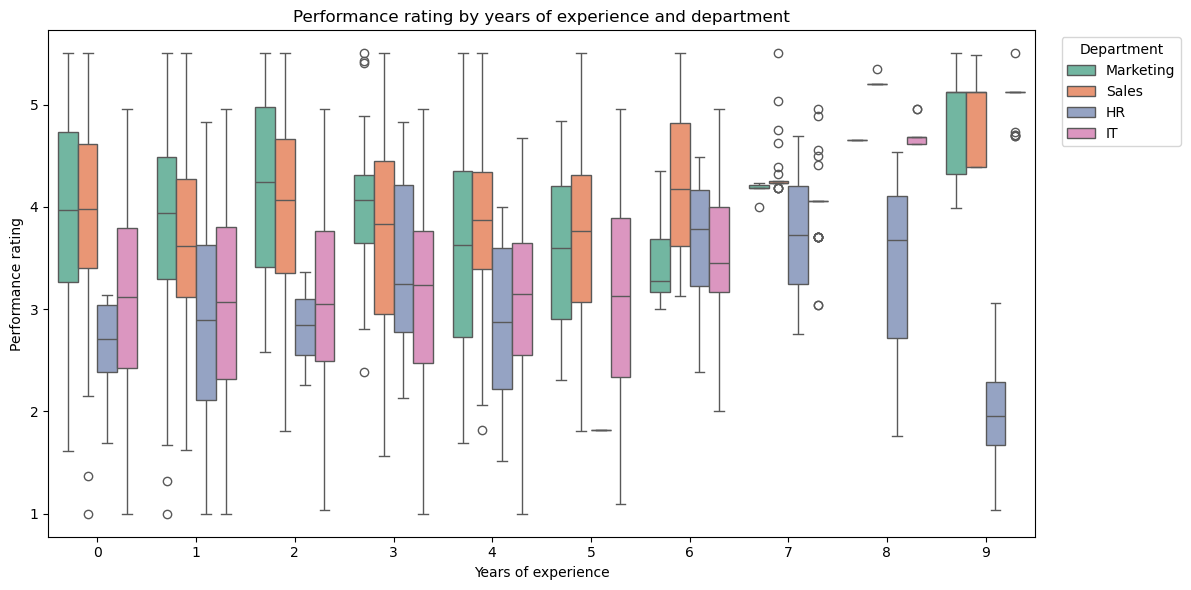

In [21]:
# Boxplot: performance rating by years of experience, split by department.
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='Experience',
    y='PerformanceRating',
    hue='Department',
    palette='Set2'
)
plt.xlabel('Years of experience')
plt.ylabel('Performance rating')
plt.title('Performance rating by years of experience and department')
plt.legend(title='Department', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### only use mean to reduce the noise from the outliers instead of median which is sensitive to outliers.

In [22]:
print(df['Experience_category'].value_counts())

Experience_category
Entry-level    647
Junior         501
Mid-level      208
Senior         112
Name: count, dtype: int64


In [23]:
dep_name=df['Department'].unique().tolist()
for dept in dep_name:
    count=len(df[df['Department']==dept])
    print(f"Department {dept} has {count} employees")

Department IT has 720 employees
Department Marketing has 240 employees
Department Sales has 445 employees
Department HR has 63 employees


`Generate sample`

In [24]:
group_IT = df[df['Department']=='IT']['PerformanceRating'] #dataframe
group_Marketing=df[df['Department']=='Marketing']['PerformanceRating']
group_Sales=df[df['Department']=='Sales']['PerformanceRating']
group_HR=df[df['Department']=='HR']['PerformanceRating']

sample_IT=group_IT.sample(n=20,random_state=20)
sample_Marketing=group_Marketing.sample(n=20,random_state=20)
sample_Sales=group_Sales.sample(n=20,random_state=20)
sample_HR=group_HR.sample(n=20,random_state=20)
sample_IT_test=group_IT.sample(n=20,random_state=5)



`ANOVA Testing`

In [25]:
#degree of freedom calculation
df_bw=len(dep_name)-1
df_wt=len(sample_IT+sample_HR+sample_Marketing+sample_Sales)-len(dep_name)
print(f"Degree of freedom between: {df_bw}")
print(f"Degree of freedom within: {df_wt}")

Degree of freedom between: 3
Degree of freedom within: 76


In [26]:
grouped_data=[df[df['Department']==dep]['PerformanceRating'] for dep in dep_name]
f_statistic, p_value= st.f_oneway(sample_HR,sample_Sales,sample_Marketing,sample_IT)
alpha=0.05
critical_f=st.f.ppf(1-alpha,df_bw,df_wt)

print("One-way ANOVA test:")
print('significant level (alpha) = 0.05')
print(f'F-statistic: {f_statistic:.2f}')
print(f'p-value: {p_value:.5f}')
print(f"Critical F-value: {critical_f:.2f}")

if (f_statistic > critical_f) & (p_value<alpha):
    print('Reject the null hypothesis, indicating that there is at least one statistically significant difference across departments.')
else:
    print("Failed to reject the null hypothesis, indicating that there is no different in the test score mean across all departments.")

One-way ANOVA test:
significant level (alpha) = 0.05
F-statistic: 6.26
p-value: 0.00074
Critical F-value: 2.72
Reject the null hypothesis, indicating that there is at least one statistically significant difference across departments.


`Post-hoc test`

In [27]:
print("\nPost-hoc analysis using Tukey's HSD test:")


Post-hoc analysis using Tukey's HSD test:


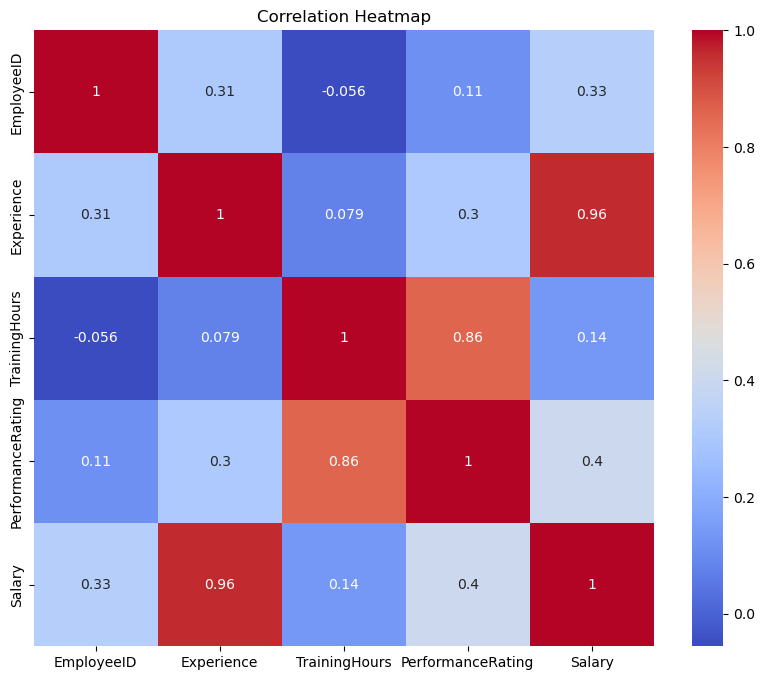

In [28]:
#AHHHHHH I don't think this is important but I'll js keep it
correlation_matrix = df[numerical_col].corr()
plt.figure(figsize = (10, 8))
sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = 'coolwarm',
)

plt.title('Correlation Heatmap')
plt.show()

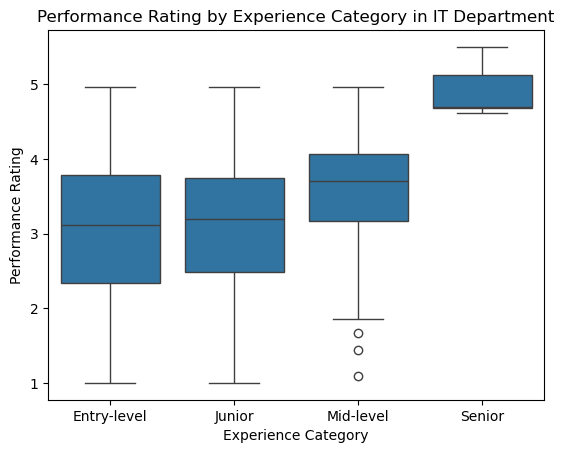

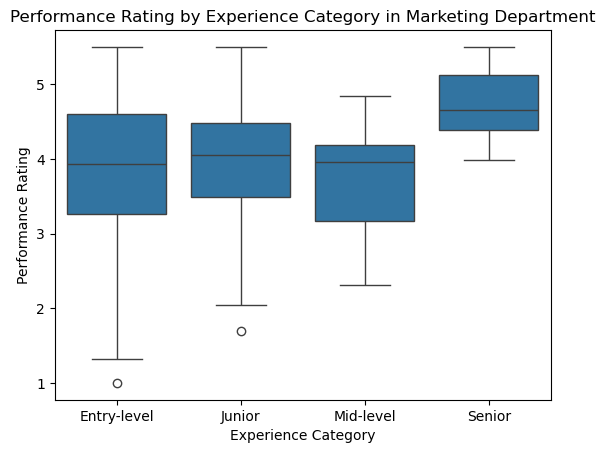

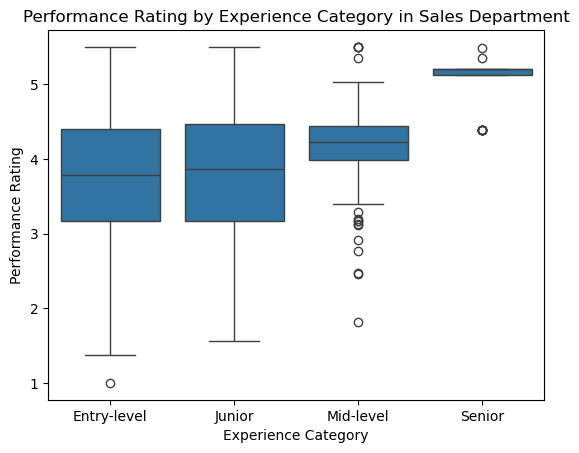

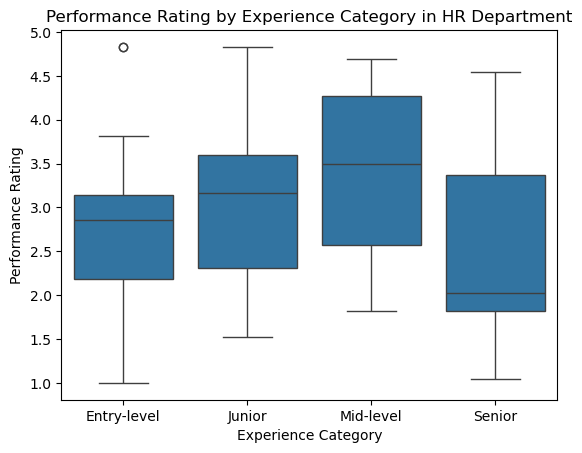

In [29]:
departments = df['Department'].unique()

for department in departments:
    department_data = df[df['Department'] == department]

    sns.boxplot(
        data = department_data,
        x = 'Experience_category',
        y = 'PerformanceRating',
        order = ['Entry-level', 'Junior', 'Mid-level', 'Senior']
    )

    plt.title(f'Performance Rating by Experience Category in {department} Department')
    plt.xlabel('Experience Category')
    plt.ylabel('Performance Rating')
    plt.show()

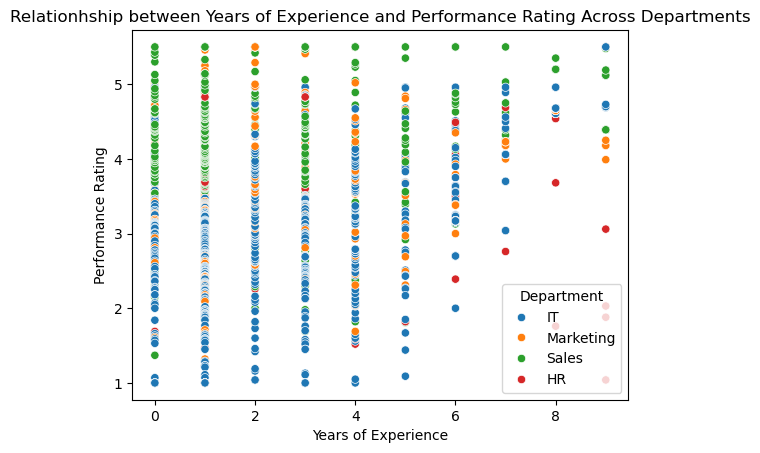

In [30]:
sns.scatterplot(
    data = df,
    x = 'Experience',
    y = 'PerformanceRating',
    hue = 'Department'
)

plt.title('Relationhship between Years of Experience and Performance Rating Across Departments')
plt.xlabel('Years of Experience')
plt.ylabel('Performance Rating')
plt.show()